In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("01 Retail Inventory.xlsx")

In [3]:
df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [5]:
df.columns

Index(['Product ID', 'Product Name', 'Category', 'Supplier Name', 'Unit Cost',
       'Retail Price', 'Opening Stock', 'Units Sold', 'Closing Stock',
       'Reorder Point', 'Stock Status'],
      dtype='object')

In [6]:
df.describe()

,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,16.061210,27.976780,262.451000,137.040000,125.411000,44.98300
std,14.172094,24.915064,140.104457,103.623232,99.023521,27.54468
min,0.520000,1.070000,20.000000,3.000000,4.000000,2.00000
25%,7.035000,11.962500,141.750000,53.000000,44.000000,22.00000
50%,12.430000,21.760000,261.000000,108.500000,96.000000,41.00000
75%,20.775000,35.307500,388.000000,204.000000,190.000000,64.25000
max,78.790000,157.400000,499.000000,463.000000,432.000000,119.00000


In [7]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df['Closing Stock'] < 0]

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status


In [10]:
category_count = df['Category'].value_counts()

print(category_count)

Category
Beauty               134
Sports & Outdoors    132
Electronics          126
Office Supplies      126
Home & Kitchen       124
Toys & Games         123
Grocery              119
Clothing             116
Name: count, dtype: int64


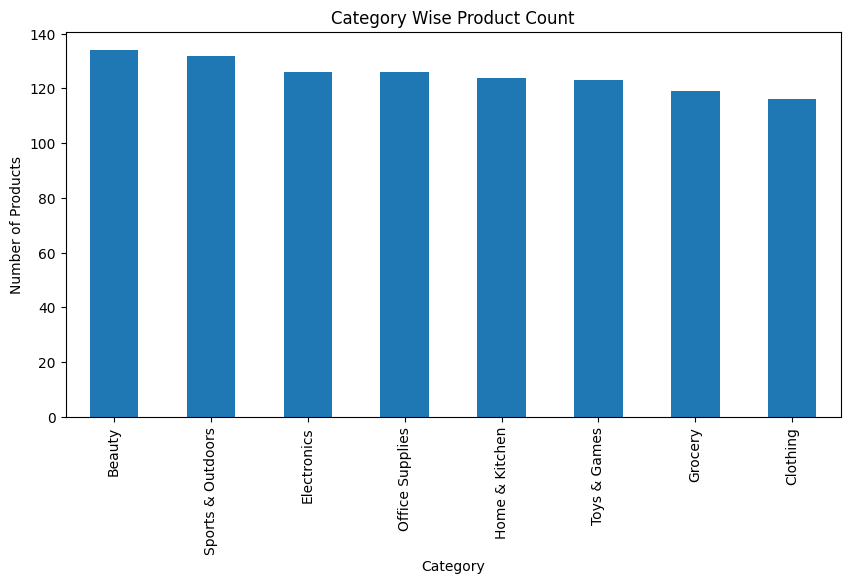

In [11]:
plt.figure(figsize=(10,5))

category_count.plot(kind='bar')

plt.title("Category Wise Product Count")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

In [12]:
category_sales = df.groupby(
    'Category'
)['Units Sold'].sum()

print(category_sales)

Category
Beauty               18137
Clothing             13736
Electronics          17621
Grocery              15364
Home & Kitchen       18387
Office Supplies      17112
Sports & Outdoors    16979
Toys & Games         19704
Name: Units Sold, dtype: int64


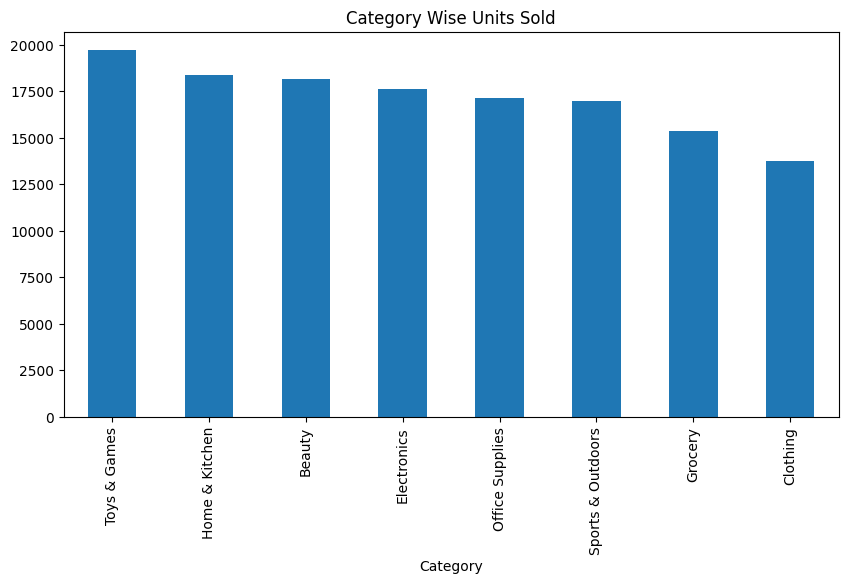

In [13]:
plt.figure(figsize=(10,5))

category_sales.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Category Wise Units Sold")

plt.show()

In [14]:
top_products = df.sort_values(
    by='Units Sold',
    ascending=False
).head(10)

top_products[
    ['Product Name','Units Sold']
]

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
970,Baseball Cap,422
550,Whistle,422
931,Rice Crackers,417
469,Building Blocks,416


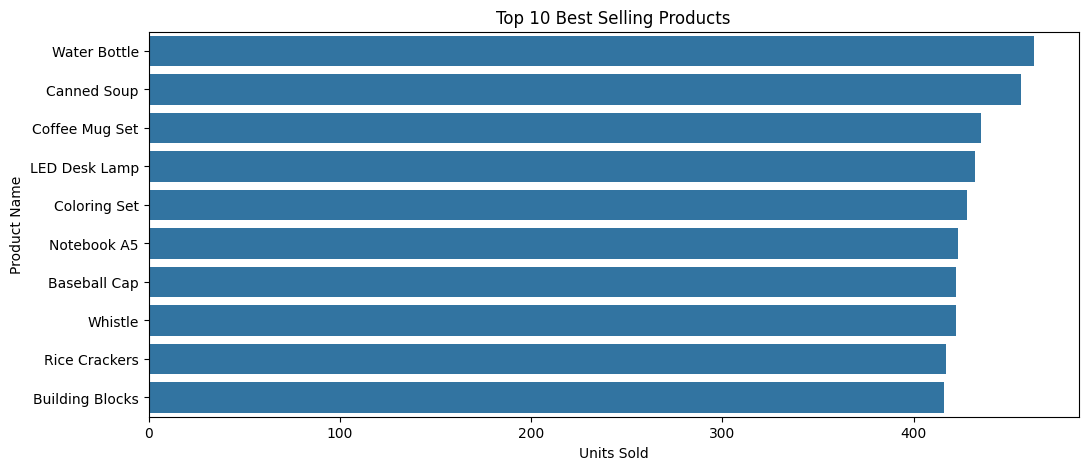

In [15]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=top_products,
    x='Units Sold',
    y='Product Name'
)

plt.title(
    "Top 10 Best Selling Products"
)

plt.show()

In [16]:
low_stock = df.sort_values(
    by='Closing Stock'
).head(10)

low_stock[
    ['Product Name','Closing Stock']
]

,Product Name,Closing Stock
45,Basic T-Shirt,4
385,Coloring Set,4
819,Notebook A5,4
654,Storage Container,4
425,Nail File Set,5
391,Eye Mask,5
703,Coffee Mug Set,5
977,Cotton Pads,6
698,Whistle,6
709,Dry Shampoo,6


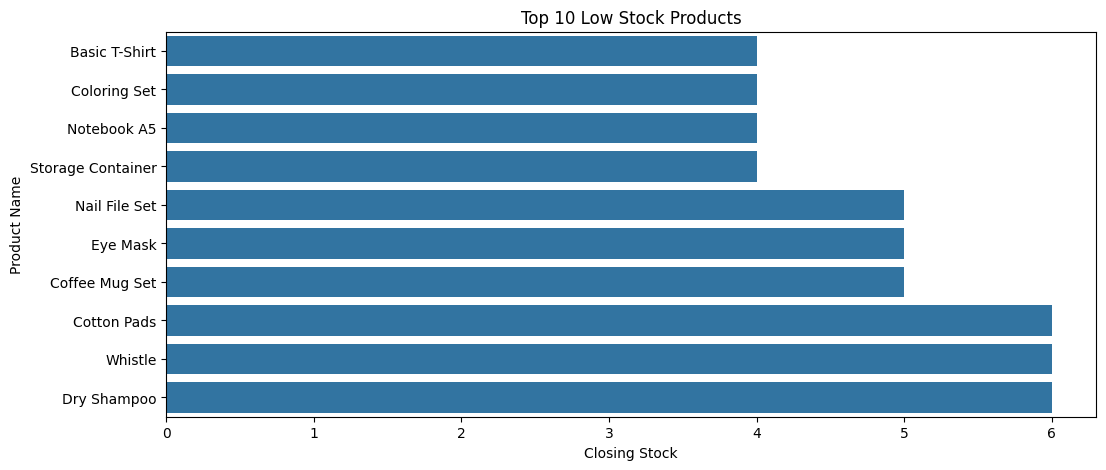

In [17]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=low_stock,
    x='Closing Stock',
    y='Product Name'
)

plt.title(
    "Top 10 Low Stock Products"
)

plt.show()

In [18]:
supplier_inventory = df.groupby(
    'Supplier Name'
)['Closing Stock'].sum()

supplier_inventory

,Closing Stock
Supplier Name,
AllGoods Supply Co,8322
Coastal Trading,13635
Global Source Direct,13916
Heritage Brands,14872
Metro Distributors,10053
National Supply Group,15606
Pacific Wholesale,10233
Premier Merchandise,14630
Summit Wholesale Inc,11595


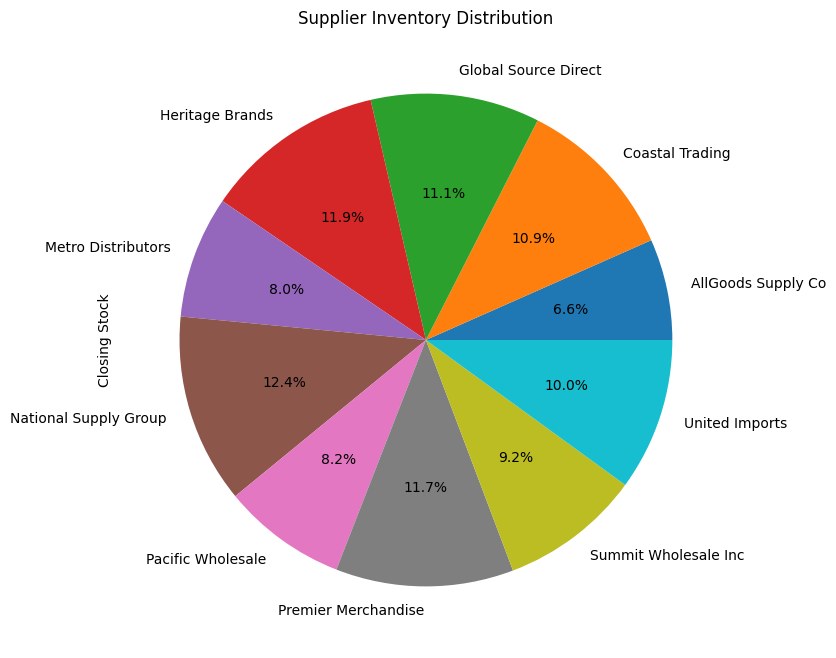

In [19]:
supplier_inventory.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title(
    "Supplier Inventory Distribution"
)

plt.show()

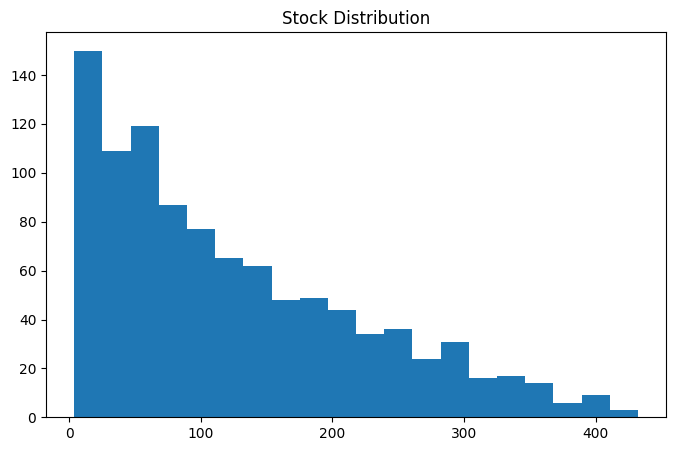

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Closing Stock'],
    bins=20
)

plt.title(
    "Stock Distribution"
)

plt.show()

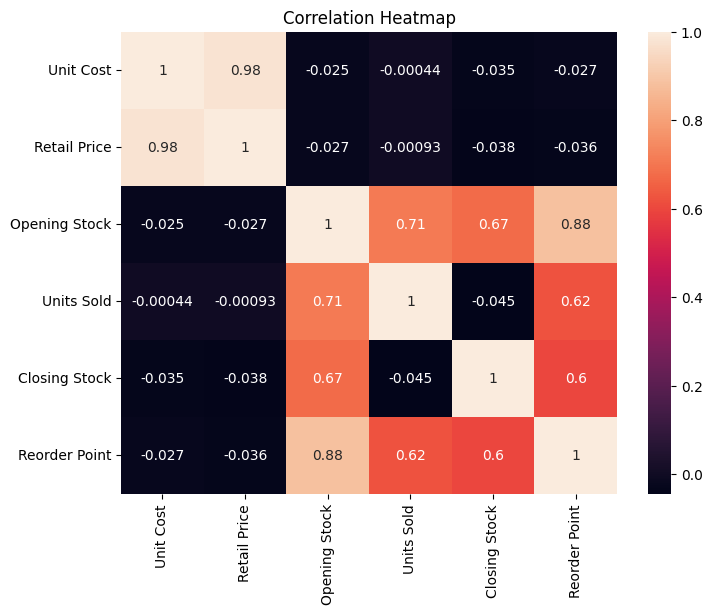

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(
        include=['int64','float64']
    ).corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [22]:
reorder_products = df[
    df['Closing Stock']
    <
    df['Reorder Point']
]

reorder_products[
    ['Product Name',
     'Closing Stock',
     'Reorder Point']
]

,Product Name,Closing Stock,Reorder Point
0,Wine Glasses,17,30
3,Action Figure,33,39
14,Bike Light,17,33
16,Desk Organizer,77,109
22,Sticky Notes,17,35
...,...,...,...
931,Rice Crackers,31,102
949,Bluetooth Adapter,10,23
970,Baseball Cap,53,87
974,Hand Cream,38,59


In [23]:
category_sales.sort_values(
    ascending=False
)

,Units Sold
Category,
Toys & Games,19704
Home & Kitchen,18387
Beauty,18137
Electronics,17621
Office Supplies,17112
Sports & Outdoors,16979
Grocery,15364
Clothing,13736


In [24]:
top_products

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
721,PRD-1722,Water Bottle,Sports & Outdoors,Summit Wholesale Inc,1.38,2.68,489,463,26,95,Low Stock
476,PRD-1477,Canned Soup,Grocery,Global Source Direct,8.12,15.92,490,456,34,56,Low Stock
791,PRD-1792,Coffee Mug Set,Home & Kitchen,Coastal Trading,12.36,17.50,471,435,36,93,Low Stock
673,PRD-1674,LED Desk Lamp,Electronics,Metro Distributors,65.20,131.63,497,432,65,76,Low Stock
810,PRD-1811,Coloring Set,Toys & Games,Pacific Wholesale,17.03,31.50,457,428,29,55,Low Stock
243,PRD-1244,Notebook A5,Office Supplies,AllGoods Supply Co,2.65,5.11,464,423,41,58,Low Stock
970,PRD-1971,Baseball Cap,Clothing,AllGoods Supply Co,11.13,24.20,475,422,53,87,Low Stock
550,PRD-1551,Whistle,Sports & Outdoors,Premier Merchandise,11.41,15.84,478,422,56,62,Low Stock
931,PRD-1932,Rice Crackers,Grocery,AllGoods Supply Co,10.45,14.70,448,417,31,102,Low Stock
469,PRD-1470,Building Blocks,Toys & Games,Heritage Brands,19.26,36.10,494,416,78,99,Low Stock


In [25]:
low_stock

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
45,PRD-1046,Basic T-Shirt,Clothing,United Imports,24.64,41.77,42,38,4,5,Low Stock
385,PRD-1386,Coloring Set,Toys & Games,Premier Merchandise,7.70,11.57,61,57,4,14,Low Stock
819,PRD-1820,Notebook A5,Office Supplies,Coastal Trading,7.80,13.91,25,21,4,2,In Stock
654,PRD-1655,Storage Container,Home & Kitchen,National Supply Group,23.10,35.70,41,37,4,4,Low Stock
425,PRD-1426,Nail File Set,Beauty,AllGoods Supply Co,16.02,32.05,88,83,5,11,Low Stock
391,PRD-1392,Eye Mask,Beauty,Pacific Wholesale,11.30,17.07,76,71,5,7,Low Stock
703,PRD-1704,Coffee Mug Set,Home & Kitchen,AllGoods Supply Co,26.38,49.78,33,28,5,8,Low Stock
977,PRD-1978,Cotton Pads,Beauty,National Supply Group,7.70,14.41,37,31,6,4,In Stock
698,PRD-1699,Whistle,Sports & Outdoors,Global Source Direct,8.74,18.95,21,15,6,3,In Stock
709,PRD-1710,Dry Shampoo,Beauty,Summit Wholesale Inc,8.93,16.55,35,29,6,3,In Stock


In [26]:
supplier_inventory

,Closing Stock
Supplier Name,
AllGoods Supply Co,8322
Coastal Trading,13635
Global Source Direct,13916
Heritage Brands,14872
Metro Distributors,10053
National Supply Group,15606
Pacific Wholesale,10233
Premier Merchandise,14630
Summit Wholesale Inc,11595
